<a href="https://colab.research.google.com/github/ManjuSrini4776/AI-based-maritime-safety-system-for-fisherman-from-crossing-international-maritime-boundary/blob/main/salary_prediction_LR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Salary with Linear Regression

**Dataset:** Years of Experience vs. Salary (30 employees)

**Goal:** Learn a straight-line model that predicts an employee's salary from their years of experience, then use it to predict a new employee's salary.



## Step 1: Upload the Dataset

Click **Choose Files** when this cell runs and select `Salary_Data.csv`.

In [1]:
# google.colab.files lets us upload a file from our own computer into this Colab session
from google.colab import files

# This opens a 'Choose Files' button. We select Salary_Data.csv from our computer.
# The file gets saved into this Colab session's temporary storage.
uploaded = files.upload()

Saving Salary_Data.csv to Salary_Data.csv


## Step 2: Import Libraries and Load the Data

In [2]:
# numpy: for numerical operations (arrays, math functions)
import numpy as np

# pandas: for loading and working with tabular data (like a spreadsheet)
import pandas as pd

# matplotlib: for plotting charts
import matplotlib.pyplot as plt

# LinearRegression: the actual machine learning model we will train
from sklearn.linear_model import LinearRegression

# train_test_split: splits our data into a training portion and a testing portion
from sklearn.model_selection import train_test_split

# metrics to judge how good our model's predictions are
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Load the CSV file we uploaded into a pandas DataFrame (a table-like structure)
df = pd.read_csv('Salary_Data.csv')

# .shape tells us (number_of_rows, number_of_columns)
print('Shape:', df.shape)

# .head(10) shows the first 10 rows so we can see what the data looks like
df.head(10)

Shape: (30, 2)


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [4]:
# .describe() gives summary statistics: count, mean, std deviation, min, max, quartiles
# This helps us sanity-check the data (e.g. is the salary range reasonable?)
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


## Step 3: Visualize the Relationship

Before modeling, we always look at the data first.

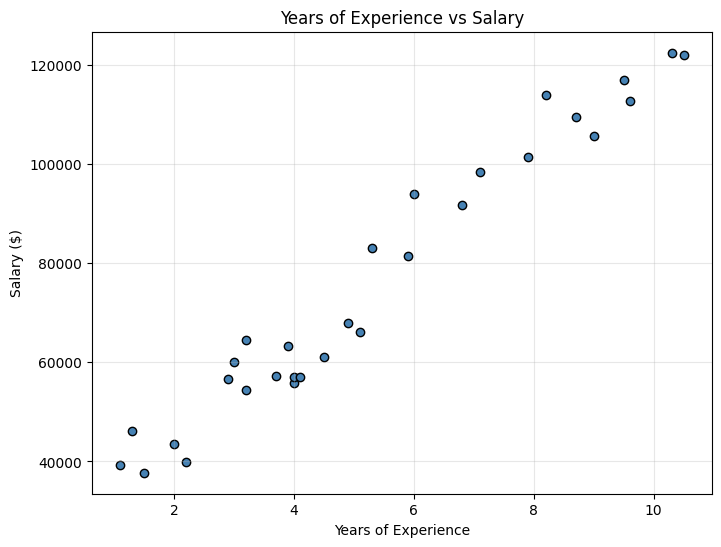

In [5]:
# Set the figure size (width=8, height=6 inches)
plt.figure(figsize=(8, 6))

# Scatter plot: one dot per employee, x = years of experience, y = salary
plt.scatter(df['YearsExperience'], df['Salary'], color='steelblue', edgecolor='black')

# Label the axes and give the chart a title
plt.xlabel('Years of Experience')
plt.ylabel('Salary ($)')
plt.title('Years of Experience vs Salary')

# Add a light grid to make the chart easier to read
plt.grid(alpha=0.3)

# Display the chart
plt.show()

# HERE the dots trend upward and to the right —
# more experience tends to go with higher salary. This roughly linear
# shape is exactly what linear regression is designed to model.

## Step 4: Split into Training and Test Sets

We train the model on part of the data, and test it on data it hasn't seen, so we can check whether it actually learned the pattern rather than memorizing it.

In [6]:
# X = the input feature(s) the model uses to make predictions.
# Double brackets [['YearsExperience']] keep it as a 2D table, which sklearn requires.
X = df[['YearsExperience']]

# y = the target value we want to predict
y = df['Salary']

# Split the data: 80% for training the model, 20% held back for testing it.
# random_state=42 makes the split reproducible (same split every time we run this).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples: {len(X_train)}')
print(f'Testing samples: {len(X_test)}')

# WHAT TO EXPLAIN HERE: with only 30 rows total, an 80/20 split gives
# roughly 24 rows to train on and 6 rows to test on.

Training samples: 24
Testing samples: 6


## Step 5: Train the Linear Regression Model

In [7]:
# Create an (untrained) Linear Regression model object
model = LinearRegression()

# .fit() is where the actual learning happens: the model finds the best-fitting
# straight line through the training data (X_train, y_train)
model.fit(X_train, y_train)

# model.coef_ is the slope of the line — how much salary changes per extra year
slope = model.coef_[0]

# model.intercept_ is where the line crosses the y-axis (predicted salary at 0 years)
intercept = model.intercept_

print(f'Slope (coefficient): {slope:.2f}')
print(f'Intercept: {intercept:.2f}')
print(f'\nModel equation: Salary = {slope:.2f} * YearsExperience + {intercept:.2f}')

# WHAT TO EXPLAIN HERE:
# - Slope: for every additional year of experience, salary increases by
#   about this many dollars.
# - Intercept: the model's predicted starting salary at 0 years of experience.
#   (This is a mathematical extrapolation, not necessarily a realistic real-world number.)

Slope (coefficient): 9423.82
Intercept: 25321.58

Model equation: Salary = 9423.82 * YearsExperience + 25321.58


## Step 6: Visualize the Fitted Line

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


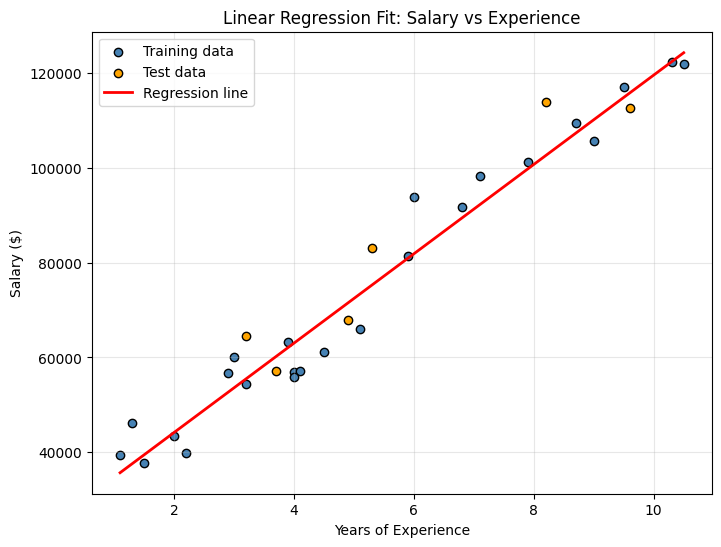

In [8]:
plt.figure(figsize=(8, 6))

# Plot the training points in blue
plt.scatter(X_train, y_train, color='steelblue', edgecolor='black', label='Training data')

# Plot the test points in orange, so we can see how the line performs on unseen data
plt.scatter(X_test, y_test, color='orange', edgecolor='black', label='Test data')

# Build a smooth line across the full range of years, and get the model's
# predicted salary at each point along that line
x_line = np.linspace(df['YearsExperience'].min(), df['YearsExperience'].max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)

# Draw the fitted regression line in red
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression line')

plt.xlabel('Years of Experience')
plt.ylabel('Salary ($)')
plt.title('Linear Regression Fit: Salary vs Experience')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# WHAT TO EXPLAIN HERE: the red line is the model's 'best guess' relationship.
# Points close to the line mean the model predicted well; points far from
# the line are cases the model got less right.

## Step 7: Evaluate the Model

In [10]:
# Use the trained model to predict salaries for the test set (data it has NOT seen)
y_pred = model.predict(X_test)

# RMSE (Root Mean Squared Error): average size of the prediction error, in dollars.
# Lower RMSE = predictions are closer to the actual values.
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R-squared: proportion (0 to 1) of the variation in salary explained by
# years of experience. Closer to 1 = the line explains the data very well.
r2 = r2_score(y_test, y_pred)

print(f'RMSE: ${rmse:,.2f}')
print(f'R\u00b2 Score: {r2:.3f}')

# WHAT TO EXPLAIN HERE: RMSE tells us, on average, how far off (in dollars)
# our predictions are. R\u00b2 close to 1 means years of experience is a strong
# predictor of salary in this dataset.

RMSE: $7,059.04
R² Score: 0.902


## Step 8: Predict a New Salary

In [11]:
# Create a new data point: someone with 12 years of experience.
# Must be a DataFrame with the same column name as the training data.
years_new = pd.DataFrame({'YearsExperience': [12]})

# Ask the trained model to predict the salary for this new input
predicted_salary = model.predict(years_new)[0]

print(f'Predicted salary for 12 years of experience: ${predicted_salary:,.2f}')

# WHAT TO EXPLAIN HERE: this is the real-world payoff — once trained, the
# model can predict an output for a brand-new input it has never seen.

Predicted salary for 12 years of experience: $138,407.37


## Summary

1. We loaded real salary data and looked at it visually first.
2. We split the data so we could fairly test the model on unseen examples.
3. We trained a Linear Regression model, which found the best-fitting straight line: `Salary = slope * YearsExperience + intercept`.
4. We evaluated the model with RMSE (average error in dollars) and R\u00b2 (how well experience explains salary).
5. We used the trained model to predict the salary for a brand-new input.

**Key idea:** Linear regression finds the straight line that best summarizes the relationship between an input (years of experience) and an output (salary), and that line can then be used to make predictions.